<a href="https://colab.research.google.com/github/RonGopal/intro_to_AI/blob/main/FinalProjectrrg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gradio

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import gradio as gr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Load dataset
df = pd.read_csv("Admission_Predict_Ver1.1.csv")

# Rename columns (remove spaces)
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

df.head()

,Serial_No.,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial_No.         500 non-null    int64  
 1   GRE_Score          500 non-null    int64  
 2   TOEFL_Score        500 non-null    int64  
 3   University_Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance_of_Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [ ]:
df.describe()

,Serial_No.,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [ ]:
df.isnull().sum()

,0
Serial_No.,0
GRE_Score,0
TOEFL_Score,0
University_Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance_of_Admit,0


In [ ]:
df.duplicated().sum()

np.int64(0)

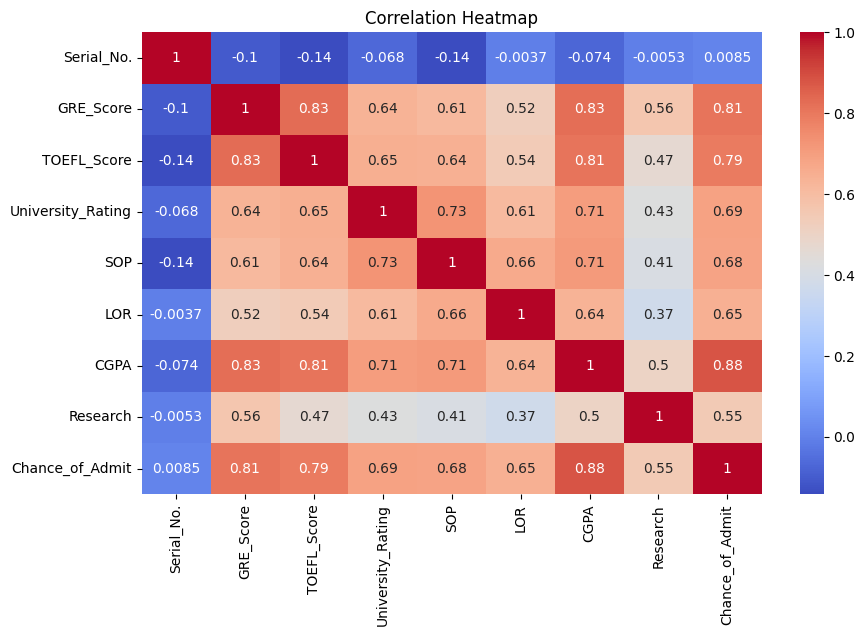

In [ ]:
# Visualize correlations between features
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

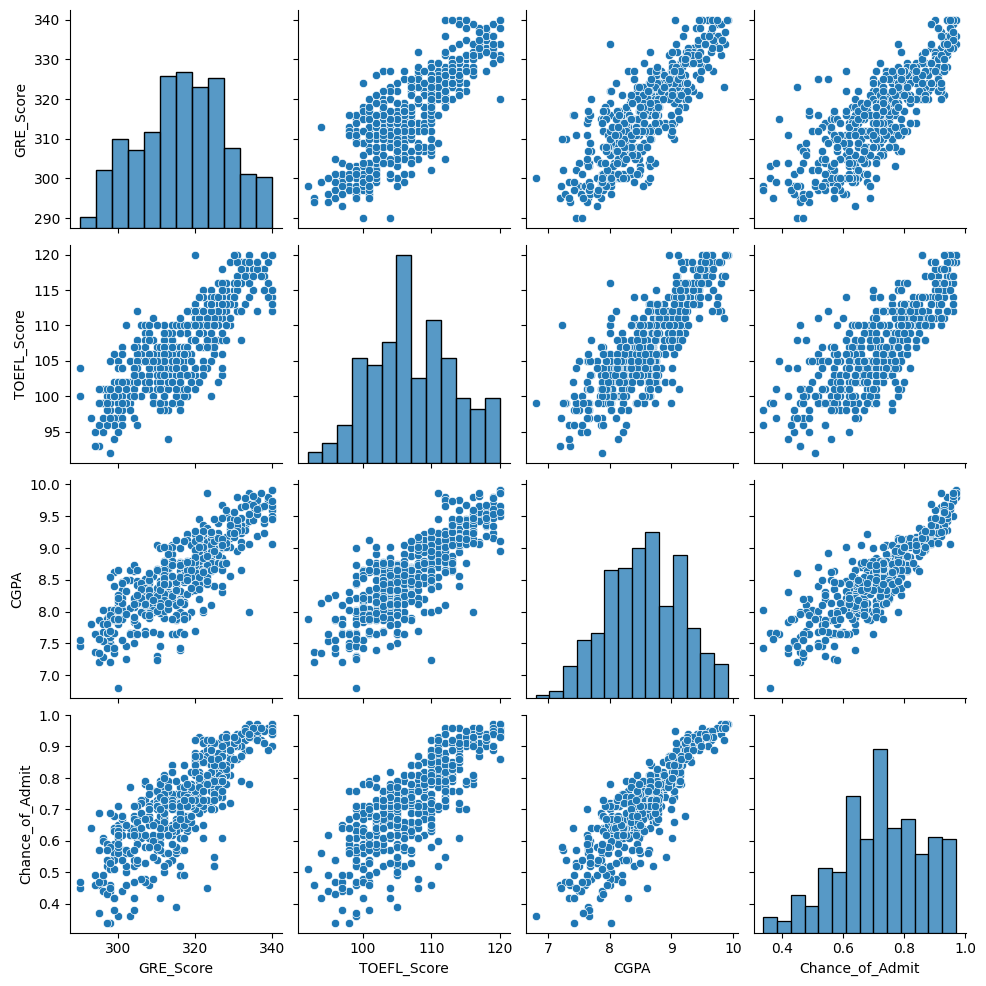

In [ ]:
# Visualize relationships between key variables
sns.pairplot(df[['GRE_Score','TOEFL_Score','CGPA','Chance_of_Admit']])

In [ ]:
# Split dataset into training and testing sets
X = df.drop(["Chance_of_Admit", "Serial_No."], axis=1)
y = df["Chance_of_Admit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Traing Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 0.06086588041578307
Linear Regression R²: 0.8188432567829631


In [ ]:
# Training Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Random Forest RMSE: 0.0653193629848615
Random Forest R²: 0.7913633652445919


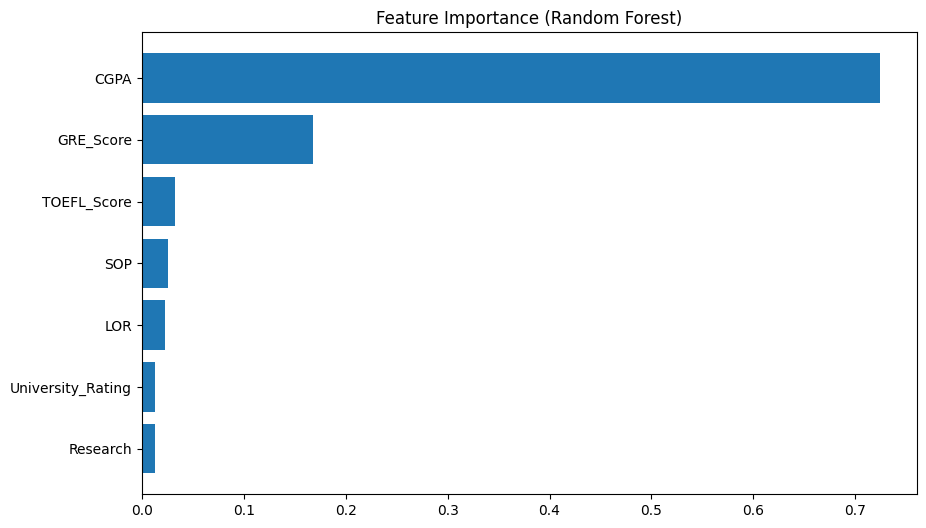

In [ ]:
# Show which features matter most in Random Forest
importances = rf.feature_importances_
feature_names = X.columns

sorted_idx = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.barh(feature_names[sorted_idx], importances[sorted_idx])
plt.title("Feature Importance (Random Forest)")
plt.show()

In [ ]:
# Define prediction function for GUI
def predict_admission(gre, toefl, rating, sop, lor, cgpa, research):
    sample = pd.DataFrame([[gre, toefl, rating, sop, lor, cgpa, research]],
                          columns=X.columns)

    lr_pred = lr.predict(sample)[0]
    rf_pred = rf.predict(sample)[0]

    return {
        "Linear Regression Prediction": round(lr_pred, 3),
        "Random Forest Prediction": round(rf_pred, 3)
    }


In [ ]:
predict_admission(
    gre=334,
    toefl=115,
    rating=5,
    sop=4.5,
    lor=4.5,
    cgpa=9.52,
    research=1
)

{'Linear Regression Prediction': np.float64(0.93),
 'Random Forest Prediction': np.float64(0.937)}

In [ ]:
predict_admission(
    gre=312,
    toefl=104,
    rating=3,
    sop=3.0,
    lor=3.5,
    cgpa=8.21,
    research=0
)

{'Linear Regression Prediction': np.float64(0.647),
 'Random Forest Prediction': np.float64(0.663)}

In [ ]:
predict_admission(
    gre=295,
    toefl=98,
    rating=2,
    sop=2.0,
    lor=2.5,
    cgpa=7.45,
    research=0
)

{'Linear Regression Prediction': np.float64(0.48),
 'Random Forest Prediction': np.float64(0.446)}

In [ ]:
# Build GUI layout
with gr.Blocks() as demo:
    gr.Markdown("# 🎓 Graduate Admission Predictor")
    gr.Markdown("Enter your academic profile to estimate your chance of admission.")

    gre = gr.Slider(250, 340, value=320, label="GRE Score")
    toefl = gr.Slider(80, 120, value=105, label="TOEFL Score")
    rating = gr.Slider(1, 5, value=3, step=1, label="University Rating")
    sop = gr.Slider(1.0, 5.0, value=3.5, step=0.5, label="SOP Strength")
    lor = gr.Slider(1.0, 5.0, value=3.5, step=0.5, label="LOR Strength")
    cgpa = gr.Slider(6.0, 10.0, value=8.5, step=0.01, label="CGPA")
    research = gr.Radio([0, 1], value=1, label="Research Experience (0 = No, 1 = Yes)")

    btn = gr.Button("Predict Admission Chance")

    output = gr.JSON(label="Model Predictions")

    btn.click(
        predict_admission,
        inputs=[gre, toefl, rating, sop, lor, cgpa, research],
        outputs=output
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f4faa702f67180c746.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


CGPA is strongest predictor of admission, maintains strengths across random forest and heatmap. Scoring 9.0 or higher gives >80%

SOP and LOR have moderate influence on acceptence, impact is nonlinear but help when acedemic scores are strong

GRE and TOEFL second strongest indicator, influences is linear and prediciatble

Linear regression produces lower r2 score

Random Forest is the model, has highest r2 score and lower RMSE. Captures nonlinear patterns and meaningful feature importance ranking